**Desafío de Ventas**

¡Bienvenidos al primer desafío!

Durante este desafío, ayudarás al Sr. Juan a decidir **qué tienda de su cadena Alura Store debe vender para iniciar un nuevo emprendimiento**. Para ello, analizarás datos de ventas, rendimiento y reseñas de las 4 tiendas de Alura Store. **El objetivo es identificar la tienda menos eficiente y presentar una recomendación final basada en los datos.**

*Lo que practicarás:*

- Cargue y manipule datos CSV con la biblioteca Pandas.

- Cree visualizaciones de datos con la biblioteca Matplotlib.

- Analice métricas como ingresos, reseñas y rendimiento de ventas.

*Requisitos:*

- Analizar datos de la tienda:

Debes evaluar información como los ingresos, las categorías más vendidas, las reseñas de los clientes, los productos más vendidos y el envío promedio.

- Crear gráficos para visualización:

Decide qué tipos de gráficos utilizar para presentar los resultados de forma clara y visual.

Mínimo de 3 gráficos diferentes, que pueden incluir gráficos de barras, circulares, de dispersión y otros.

- Enviar una recomendación:

Después del análisis, escriba un texto explicando a qué tienda debería vender el Sr. Juan y por qué, basándose en los datos presentados.

# Importación de datos



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

# Preparación de Datos

## Concatenar todos los DataFrames


In [2]:
# Pasar todas las tiendas a un solo DF e indicar "Tienda Origen"
all_tiendas_df = pd.concat([tienda, tienda2, tienda3, tienda4], keys=['tienda1', 'tienda2', 'tienda3', 'tienda4'])
all_tiendas_df = all_tiendas_df.reset_index(level=0).rename(columns={'level_0': 'Tienda Origen'})
all_tiendas_df.head()

,Tienda Origen,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,tienda1,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,tienda1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,tienda1,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,tienda1,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,tienda1,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


# Exploración de datos

In [3]:
tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [4]:
# Filas y dimensiones de cada DF
print(tienda.shape)
print(tienda2.shape)
print(tienda3.shape)
print(tienda4.shape)

(2359, 12)
(2359, 12)
(2359, 12)
(2358, 12)


In [5]:
tienda2.sample(10)

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
284,Mochila,Deportes y diversión,87000.0,5000.0,08/01/2022,Blanca Ramirez,Bogotá,5,Tarjeta de crédito,2,4.60971,-74.08175
2059,Smart TV,Electrónicos,1415500.0,75600.0,15/06/2021,Camila Rivera,Riohacha,1,Tarjeta de crédito,1,11.54444,-72.90722
63,Ciencia de datos con Python,Libros,61600.0,1500.0,01/02/2023,Blanca Ramirez,Bogotá,5,Tarjeta de crédito,2,4.60971,-74.08175
864,Ciencia de datos con Python,Libros,62000.0,1500.0,27/08/2021,Blanca Ramirez,Bogotá,5,Tarjeta de débito,1,4.60971,-74.08175
554,Ajedrez de madera,Juguetes,25100.0,7200.0,02/09/2021,Rafael Acosta,Cali,5,Tarjeta de crédito,1,3.43722,-76.52250
1498,Balón de baloncesto,Deportes y diversión,52200.0,3200.0,07/10/2020,Izabela de León,Cali,5,Nequi,1,3.43722,-76.52250
447,Smart TV,Electrónicos,1234000.0,71600.0,08/05/2022,Juan Fernandez,Medellín,3,Tarjeta de crédito,6,6.25184,-75.56359
314,Balón de baloncesto,Deportes y diversión,25900.0,1800.0,13/12/2020,Blanca Ramirez,Medellín,4,Tarjeta de crédito,9,6.25184,-75.56359
223,Silla de oficina,Muebles,432100.0,21200.0,25/12/2021,Camila Rivera,Medellín,1,Tarjeta de crédito,3,6.25184,-75.56359
2173,Olla de presión,Artículos para el hogar,88100.0,7100.0,20/03/2020,Juan Fernandez,Bogotá,5,Nequi,1,4.60971,-74.08175


## Producto y Categoría: Artículos vendidos y sus calificaciones.

In [6]:
tienda.query('Producto == "Mesa de comedor"')

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
97,Mesa de comedor,Muebles,279300.0,15300.0,03/05/2022,Santiago Silva,Bogotá,2,Tarjeta de crédito,6,4.60971,-74.08175
186,Mesa de comedor,Muebles,217000.0,9700.0,14/09/2021,Pedro Gomez,Pereira,1,Cupón,1,4.81333,-75.69611
220,Mesa de comedor,Muebles,160300.0,9200.0,25/10/2020,Lucas Olivera,Bogotá,4,Nequi,1,4.60971,-74.08175
226,Mesa de comedor,Muebles,218600.0,12300.0,21/02/2021,Lucas Olivera,Cali,1,Nequi,1,3.43722,-76.52250
238,Mesa de comedor,Muebles,338900.0,18700.0,10/02/2022,Pedro Gomez,Bogotá,5,Nequi,1,4.60971,-74.08175
256,Mesa de comedor,Muebles,176300.0,7600.0,11/12/2020,Ángel Rodriguez,Bogotá,4,Tarjeta de crédito,1,4.60971,-74.08175
356,Mesa de comedor,Muebles,374200.0,20300.0,08/03/2021,Juliana Costa,Bogotá,5,Tarjeta de crédito,4,4.60971,-74.08175
382,Mesa de comedor,Muebles,228400.0,20000.0,31/03/2023,Felipe Santos,Bogotá,3,Nequi,1,4.60971,-74.08175
401,Mesa de comedor,Muebles,157900.0,13200.0,02/05/2021,Felipe Santos,Bogotá,3,Tarjeta de crédito,1,4.60971,-74.08175


In [7]:
display(tienda['Producto'].unique())

array(['Asistente virtual', 'Mesa de comedor', 'Juego de mesa',
       'Microondas', 'Silla de oficina', 'Bloques de construcción',
       'Muñeca bebé', 'Lavavajillas', 'Lavadora de ropa',
       'Carrito de control remoto', 'Refrigerador', 'Auriculares',
       'Olla de presión', 'Bicicleta', 'Ciencia de datos con Python',
       'Balón de voleibol', 'Ajedrez de madera', 'TV LED UHD 4K',
       'Vaso térmico', 'Kit de bancas', 'Dashboards con Power BI',
       'Cubertería', 'Set de ollas', 'Batería', 'Cuerda para saltar',
       'Estufa', 'Cama box', 'Impresora', 'Mesa de noche', 'Armario',
       'Dinosaurio Rex', 'Guitarra eléctrica', 'Secadora de ropa',
       'Sofá reclinable', 'Tablet ABXY', 'Cubo mágico 8x8',
       'Set de vasos', 'Modelado predictivo', 'Iphone 15', 'Mochila',
       'Balón de baloncesto', 'Auriculares con micrófono', 'Sillón',
       'Guitarra acústica', 'Iniciando en programación', 'Celular ABXY',
       'Smartwatch', 'Mesa de centro', 'Cama king', 'Smart TV

### Cantidad de Productos vendidos por Categoría en la Tienda 1

In [8]:
categoria_counts = tienda.groupby('Categoría del Producto').size().reset_index(name='Cantidad de Productos')
display(categoria_counts)

,Categoría del Producto,Cantidad de Productos
0,Artículos para el hogar,171
1,Deportes y diversión,284
2,Electrodomésticos,312
3,Electrónicos,448
4,Instrumentos musicales,182
5,Juguetes,324
6,Libros,173
7,Muebles,465


## Precio y Envío: Valores de venta y costos asociados.

In [9]:
tienda3['Precio'].max()

2968200.0

### Producto más caro de la Tienda3

In [10]:
print(f'Precio más caro de la tienda3: {tienda3['Precio'].max()}')

# Obtener lista de productos cuyo precio sea igual al precio máximo
producto_mas_caro = tienda3.loc[tienda3['Precio'] == tienda3['Precio'].max()]

# Mostrar lista
display(producto_mas_caro[['Producto', 'Precio']])

Precio más caro de la tienda3: 2968200.0


,Producto,Precio
2295,TV LED UHD 4K,2968200.0


## Fecha y ubicación de compra: Información temporal y geográfica.

In [11]:
# Convertir columna 'Fecha de Compra' en tipo de dato DATETIME
tienda['Fecha de Compra'] = pd.to_datetime(tienda['Fecha de Compra'], format='%d/%m/%Y')
tienda2['Fecha de Compra'] = pd.to_datetime(tienda2['Fecha de Compra'], format='%d/%m/%Y')
tienda3['Fecha de Compra'] = pd.to_datetime(tienda3['Fecha de Compra'], format='%d/%m/%Y')
tienda4['Fecha de Compra'] = pd.to_datetime(tienda4['Fecha de Compra'], format='%d/%m/%Y')
print("Conversion to datetime complete for 'Fecha de Compra' in all DataFrames.")

Conversion to datetime complete for 'Fecha de Compra' in all DataFrames.


In [12]:
print(type('Fecha de Compra'))
tienda['Fecha de Compra'].sample(10)

<class 'str'>


,Fecha de Compra
168,2021-02-08
321,2022-12-10
479,2020-01-06
1687,2020-06-08
52,2022-08-06
1392,2021-04-22
2224,2020-10-16
2353,2022-12-30
1621,2020-09-08
1385,2021-02-01


## Evaluación de compra: Comentarios de clientes.

In [13]:
display(tienda['Calificación'].unique())

array([4, 1, 5, 3, 2])

In [14]:
# Filtrar all_tiendas_df para tienda1 y calificaciones buenas (4 o 5)
productos_buenas_calificaciones_tienda1 = all_tiendas_df[
    (all_tiendas_df['Tienda Origen'] == 'tienda1') &
    (all_tiendas_df['Calificación'] >= 4)
]

# Agrupar por producto y contar las calificaciones
conteo_buenas_calificaciones = productos_buenas_calificaciones_tienda1.groupby('Producto').size().reset_index(name='Cantidad de Buenas Calificaciones')

# Encontrar el producto con la mayor cantidad de buenas calificaciones
producto_mas_calificaciones_buenas = conteo_buenas_calificaciones.loc[conteo_buenas_calificaciones['Cantidad de Buenas Calificaciones'].idxmax()]

print("Producto de la tienda1 con mayor cantidad de calificaciones buenas:")
display(producto_mas_calificaciones_buenas)


Producto de la tienda1 con mayor cantidad de calificaciones buenas:


,1
Producto,Armario
Cantidad de Buenas Calificaciones,46


## Tipo de Pago y Cuotas: Métodos utilizados por los clientes.

In [15]:
display(tienda['Método de pago'].unique())
display(tienda[['Método de pago','Cantidad de cuotas']].sample(10))


array(['Tarjeta de crédito', 'Nequi', 'Cupón', 'Tarjeta de débito'],
      dtype=object)

,Método de pago,Cantidad de cuotas
2113,Tarjeta de crédito,8
843,Tarjeta de crédito,4
2322,Tarjeta de crédito,1
1999,Tarjeta de crédito,1
2130,Tarjeta de crédito,2
33,Tarjeta de crédito,1
1667,Tarjeta de crédito,8
684,Cupón,1
2309,Tarjeta de crédito,1
829,Tarjeta de crédito,2


In [16]:
all_tiendas_df['Metodo_Cuotas_Combinado'] = all_tiendas_df['Método de pago'] + ' en ' + all_tiendas_df['Cantidad de cuotas'].astype(str) + ' cuota(s)'

metodo_cuotas_mas_habitual = all_tiendas_df['Metodo_Cuotas_Combinado'].value_counts().idxmax()

print(f"El método de pago y la cantidad de cuotas más habitual es: {metodo_cuotas_mas_habitual}")

El método de pago y la cantidad de cuotas más habitual es: Tarjeta de crédito en 1 cuota(s)


In [17]:
metodo_cuotas_mas_habitual

'Tarjeta de crédito en 1 cuota(s)'

## Coordenadas Geográficas: Ubicación de las transacciones.

In [18]:
tienda

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,2021-01-16,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,2022-05-18,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,2021-03-15,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,2022-05-03,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,2020-11-07,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359
...,...,...,...,...,...,...,...,...,...,...,...,...
2354,Iphone 15,Electrónicos,1284400.0,66600.0,2021-11-15,Izabela de León,Medellín,1,Nequi,1,6.25184,-75.56359
2355,Impresora,Electrónicos,282800.0,15300.0,2023-03-18,Lucas Olivera,Bogotá,5,Nequi,1,4.60971,-74.08175
2356,Juego de mesa,Juguetes,122900.0,7200.0,2021-07-06,Lucas Olivera,Cali,5,Tarjeta de crédito,4,3.43722,-76.52250
2357,Cama box,Muebles,691300.0,35000.0,2022-05-02,Pedro Gomez,Pasto,1,Tarjeta de crédito,2,1.21361,-77.28111


In [19]:
display(tienda['Lugar de Compra'].unique())
display(tienda[['Lugar de Compra','lat', 'lon']].sample(10))

array(['Bogotá', 'Medellín', 'Cartagena', 'Cali', 'Santa Marta',
       'Pereira', 'Barranquilla', 'Villavicencio', 'Inírida', 'Cúcuta',
       'Manizales', 'Neiva', 'Bucaramanga', 'Valledupar', 'Pasto',
       'Riohacha', 'Armenia', 'Leticia', 'Soacha'], dtype=object)

,Lugar de Compra,lat,lon
1787,Bogotá,4.60971,-74.08175
1280,Cali,3.43722,-76.52250
177,Bogotá,4.60971,-74.08175
2212,Cali,3.43722,-76.52250
1229,Cúcuta,7.89391,-72.50782
1738,Bogotá,4.60971,-74.08175
1311,Bogotá,4.60971,-74.08175
1492,Pereira,4.81333,-75.69611
665,Medellín,6.25184,-75.56359
700,Bogotá,4.60971,-74.08175


In [20]:
compras_por_lugar = all_tiendas_df['Lugar de Compra'].value_counts().reset_index()
compras_por_lugar.columns = ['Lugar de Compra', 'Cantidad de Compras']
lugar_mas_compras = compras_por_lugar.loc[compras_por_lugar['Cantidad de Compras'].idxmax()]

print(f"El lugar donde se realizan más compras es: {lugar_mas_compras['Lugar de Compra']} con {lugar_mas_compras['Cantidad de Compras']} compras.")
display(lugar_mas_compras)

El lugar donde se realizan más compras es: Bogotá con 3943 compras.


,0
Lugar de Compra,Bogotá
Cantidad de Compras,3943


# Análisis

## 1. Análisis de facturación

En este primer análisis, debes calcular el ingreso total de cada tienda. Sumando los valores de la columna Precio de cada conjunto de datos de la tienda para estimar los ingresos.

In [21]:
# Agrupar ingresos por tienda, sumando la columna Precio para cada una de ellas
ingreso_total_por_tienda = all_tiendas_df.groupby('Tienda Origen')['Precio'].sum().reset_index()
ingreso_total_por_tienda.rename(columns={'Precio': 'Ingreso Total'}, inplace=True)
display(ingreso_total_por_tienda)

,Tienda Origen,Ingreso Total
0,tienda1,1.150880e+09
1,tienda2,1.116344e+09
2,tienda3,1.098020e+09
3,tienda4,1.038376e+09


In [22]:
tienda_mas_ingresos = ingreso_total_por_tienda.loc[ingreso_total_por_tienda['Ingreso Total'].idxmax()]

print(f"La tienda con más ingresos es: {tienda_mas_ingresos['Tienda Origen']} con {tienda_mas_ingresos['Ingreso Total']} ingresos.\n")
display(tienda_mas_ingresos)

La tienda con más ingresos es: tienda1 con 1150880400.0 ingresos.



,0
Tienda Origen,tienda1
Ingreso Total,1150880400.0


In [23]:
tienda_menos_ingresos = ingreso_total_por_tienda.loc[ingreso_total_por_tienda['Ingreso Total'].idxmin()]

print(f"La tienda con menos ingresos es: {tienda_menos_ingresos['Tienda Origen']} con {tienda_menos_ingresos['Ingreso Total']} ingresos.")
display(tienda_menos_ingresos)

La tienda con menos ingresos es: tienda4 con 1038375700.0 ingresos.


,3
Tienda Origen,tienda4
Ingreso Total,1038375700.0


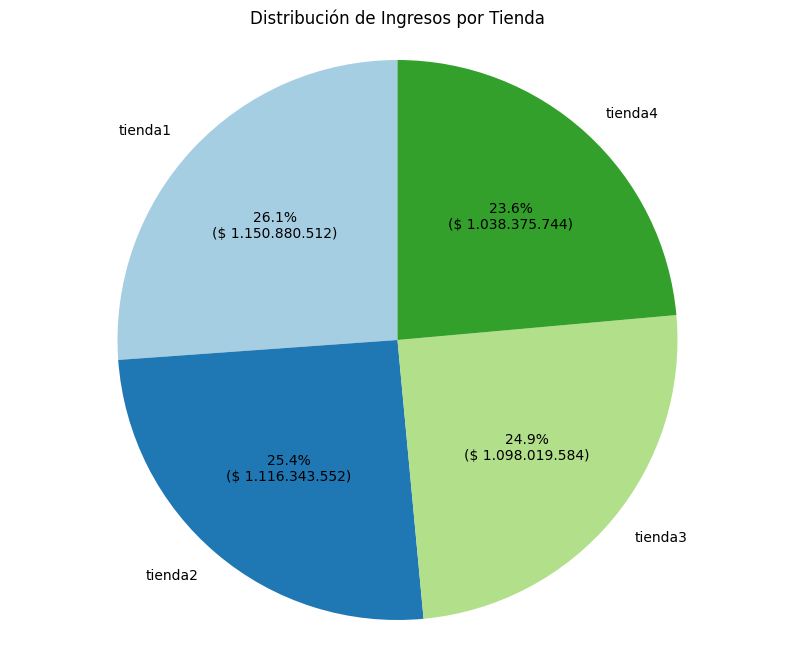

In [24]:
import matplotlib.pyplot as plt

# Función para formatear las etiquetas del gráfico circular
def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{:.1f}%\n($ {:,.0f})'.format(pct, val).replace(',', '.')
    return my_format

# Crear el gráfico circular
plt.figure(figsize=(10, 8))
plt.pie(ingreso_total_por_tienda['Ingreso Total'],
        labels=ingreso_total_por_tienda['Tienda Origen'],
        autopct=autopct_format(ingreso_total_por_tienda['Ingreso Total']),
        startangle=90,
        colors=plt.cm.Paired.colors)
plt.title('Distribución de Ingresos por Tienda')
plt.axis('equal') # Asegura que el círculo sea proporcional
plt.show()

## 2. Ventas por categoría

En este debes calcular la cantidad de productos vendidos por categoría en cada tienda. La idea es agrupar los datos por categoría y contar el número de ventas de cada tipo, mostrando las categorías más populares de cada tienda.

In [25]:
ventas_por_categoria_por_tienda = all_tiendas_df.groupby(['Tienda Origen', 'Categoría del Producto']).size().reset_index(name='Cantidad de Ventas')
display(ventas_por_categoria_por_tienda)

,Tienda Origen,Categoría del Producto,Cantidad de Ventas
0,tienda1,Artículos para el hogar,171
1,tienda1,Deportes y diversión,284
2,tienda1,Electrodomésticos,312
3,tienda1,Electrónicos,448
4,tienda1,Instrumentos musicales,182
5,tienda1,Juguetes,324
6,tienda1,Libros,173
7,tienda1,Muebles,465
8,tienda2,Artículos para el hogar,181
9,tienda2,Deportes y diversión,275


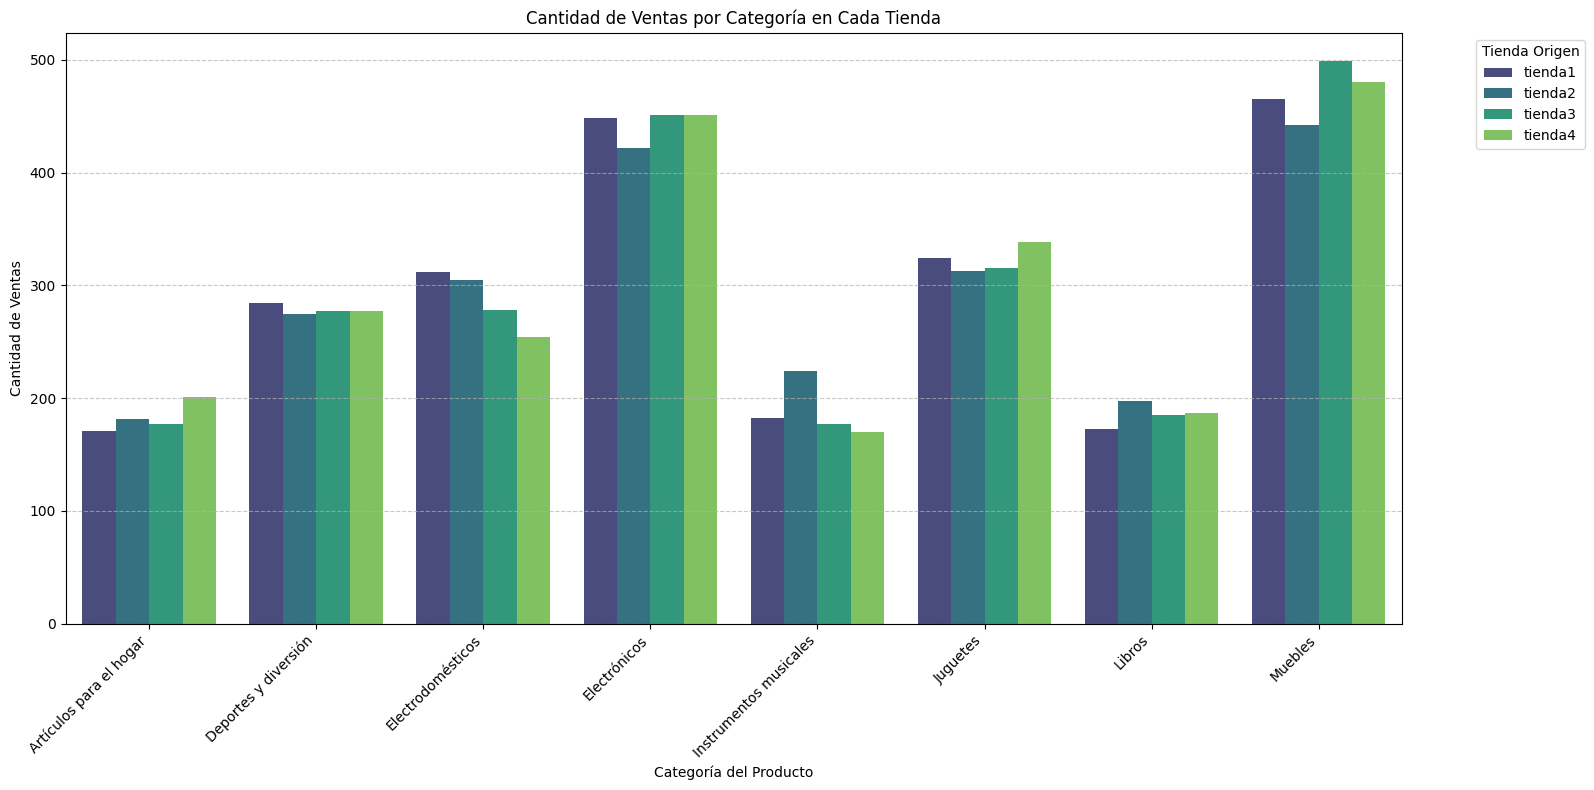

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8))
sns.barplot(
    data=ventas_por_categoria_por_tienda,
    x='Categoría del Producto',
    y='Cantidad de Ventas',
    hue='Tienda Origen',
    palette='viridis' # Paleta de colores para las tiendas
)

plt.title('Cantidad de Ventas por Categoría en Cada Tienda')
plt.xlabel('Categoría del Producto')
plt.ylabel('Cantidad de Ventas')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Tienda Origen', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 3. Calificación promedio de la tienda
En este paso, debes calcular las calificaciones promedio de los clientes para cada tienda. El objetivo es conocer la satisfacción del cliente con los productos vendidos.

In [27]:
calificacion_promedio_por_tienda = all_tiendas_df.groupby('Tienda Origen')['Calificación'].mean().reset_index()
calificacion_promedio_por_tienda.rename(columns={'Calificación': 'Calificación Promedio'}, inplace=True)
display(calificacion_promedio_por_tienda)

,Tienda Origen,Calificación Promedio
0,tienda1,3.976685
1,tienda2,4.037304
2,tienda3,4.048326
3,tienda4,3.995759


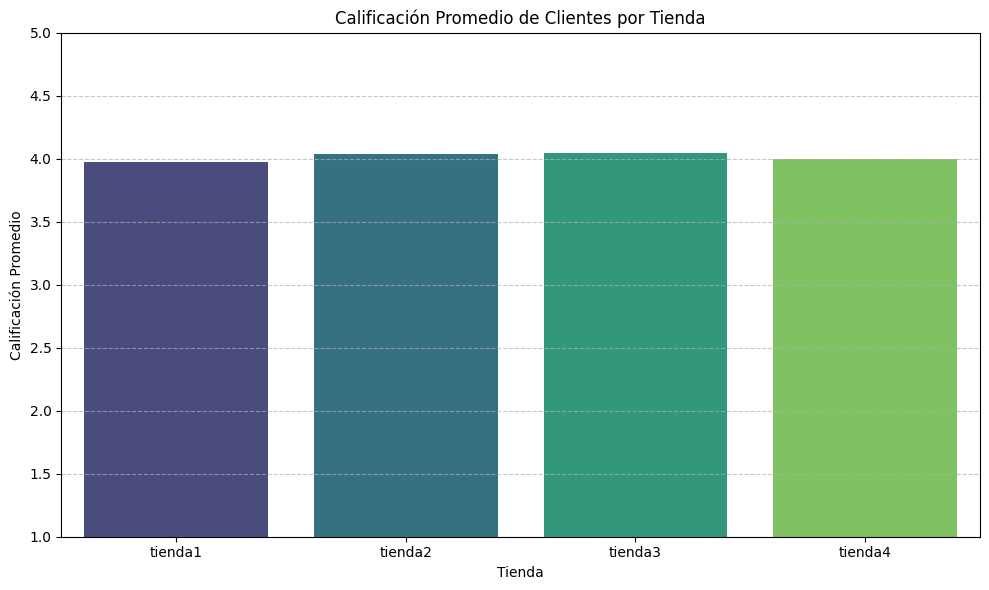

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(
    data=calificacion_promedio_por_tienda,
    x='Tienda Origen',
    y='Calificación Promedio',
    hue='Tienda Origen', # Asignar 'Tienda Origen' a hue para mantener la paleta de colores
    palette='viridis',
    legend=False # Desactivar la leyenda ya que la información está en el eje x
)

plt.title('Calificación Promedio de Clientes por Tienda')
plt.xlabel('Tienda')
plt.ylabel('Calificación Promedio')
plt.ylim(1, 5) # Las calificaciones van de 1 a 5
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 4. Productos más y menos vendidos
En este paso, debes identificar qué productos fueron los más vendidos y los menos vendidos en cada tienda. Visualiza los resultados para que quede claro qué productos destacaron en ventas en cada tienda.

In [43]:
# Generar ventas_por_producto_y_tienda
ventas_por_producto_y_tienda = all_tiendas_df.groupby(['Tienda Origen', 'Producto']).size().reset_index(name='Cantidad de Ventas')

# Generar productos_mas_vendidos
productos_mas_vendidos = ventas_por_producto_y_tienda.groupby('Tienda Origen').apply(lambda x: x.sort_values(by='Cantidad de Ventas', ascending=False).head(5)).reset_index(drop=True)
display(productos_mas_vendidos.head())

/tmp/ipython-input-2112799376.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  productos_mas_vendidos = ventas_por_producto_y_tienda.groupby('Tienda Origen').apply(lambda x: x.sort_values(by='Cantidad de Ventas', ascending=False).head(5)).reset_index(drop=True)


,Tienda Origen,Producto,Cantidad de Ventas
0,tienda1,Armario,60
1,tienda1,TV LED UHD 4K,60
2,tienda1,Microondas,60
3,tienda1,Secadora de ropa,58
4,tienda1,Mesa de noche,56


In [44]:
# Generar productos_menos_vendidos
productos_menos_vendidos = ventas_por_producto_y_tienda.sort_values(by=['Tienda Origen', 'Cantidad de Ventas'], ascending=[True, True]) \
                                     .groupby('Tienda Origen') \
                                     .head(5) \
                                     .reset_index(drop=True)
display(productos_menos_vendidos.head())

,Tienda Origen,Producto,Cantidad de Ventas
0,tienda1,Auriculares con micrófono,33
1,tienda1,Celular ABXY,33
2,tienda1,Olla de presión,35
3,tienda1,Pandereta,36
4,tienda1,Ciencia de datos con Python,39


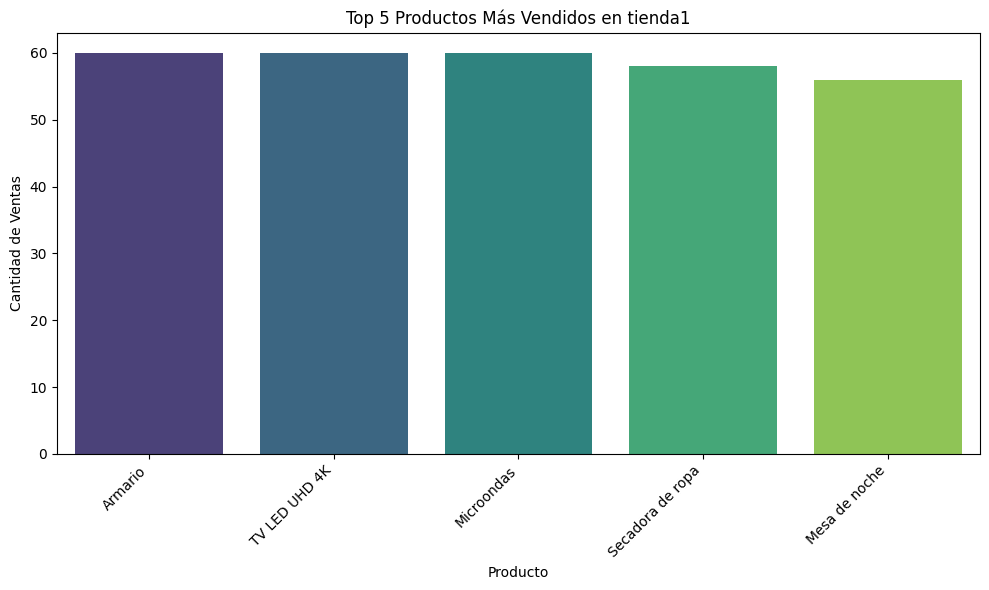

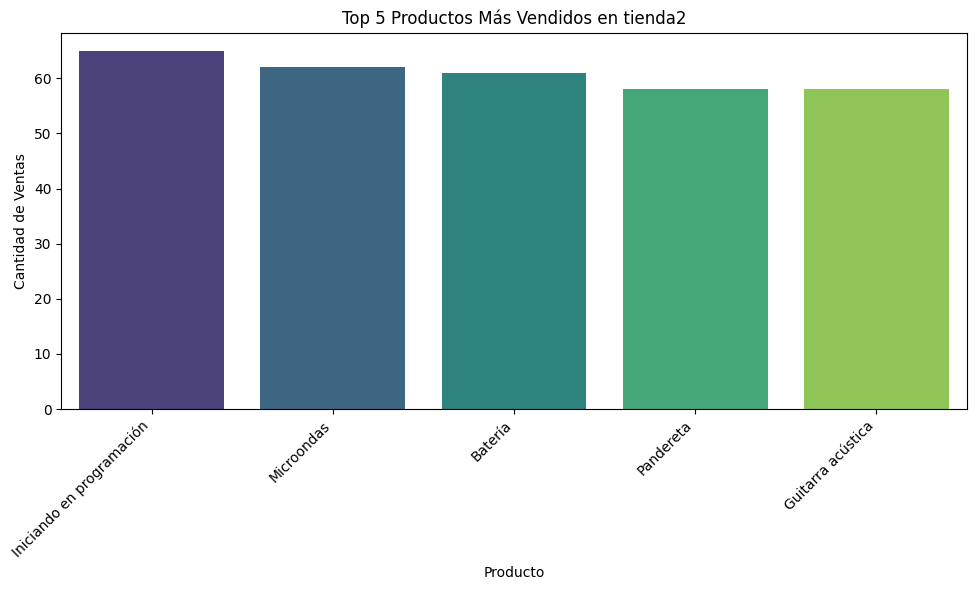

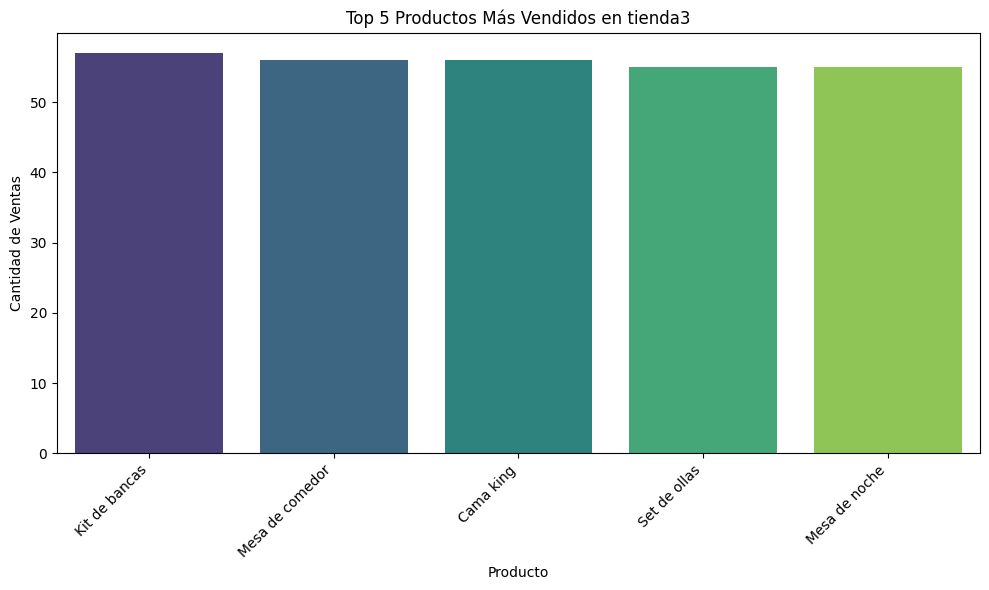

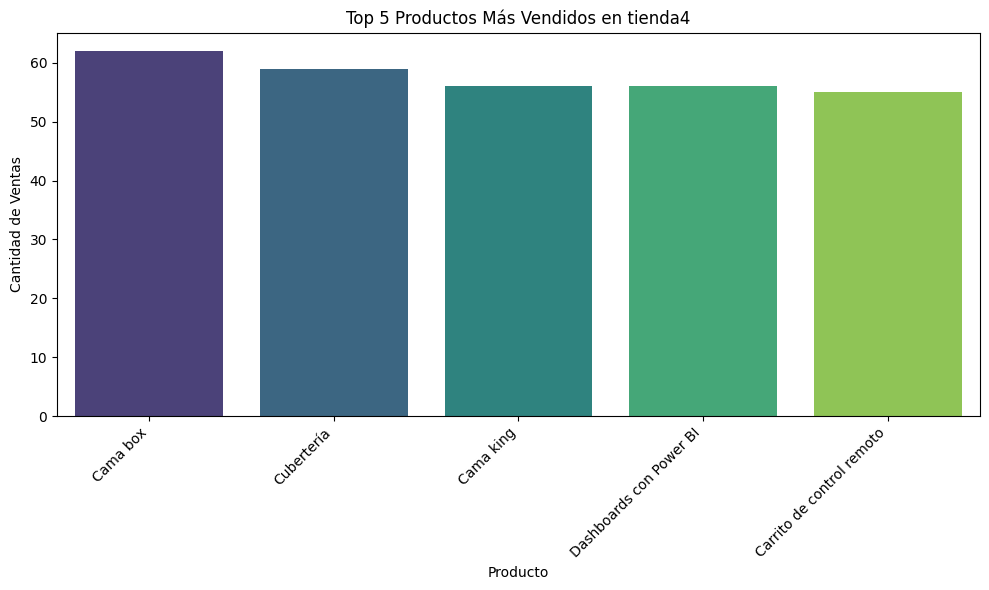

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizar productos más vendidos
for tienda_origen in productos_mas_vendidos['Tienda Origen'].unique():
    df_tienda = productos_mas_vendidos[productos_mas_vendidos['Tienda Origen'] == tienda_origen]

    plt.figure(figsize=(10, 6))
    sns.barplot(
        x='Producto',
        y='Cantidad de Ventas',
        data=df_tienda,
        hue='Producto', # Asignar 'Producto' a hue para colorear cada barra según el producto
        palette='viridis',
        legend=False # Desactivar la leyenda ya que la información está en el eje x
    )
    plt.xlabel('Producto')
    plt.ylabel('Cantidad de Ventas')
    plt.title(f'Top 5 Productos Más Vendidos en {tienda_origen}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

**Visualizando los Productos Menos Vendidos:**

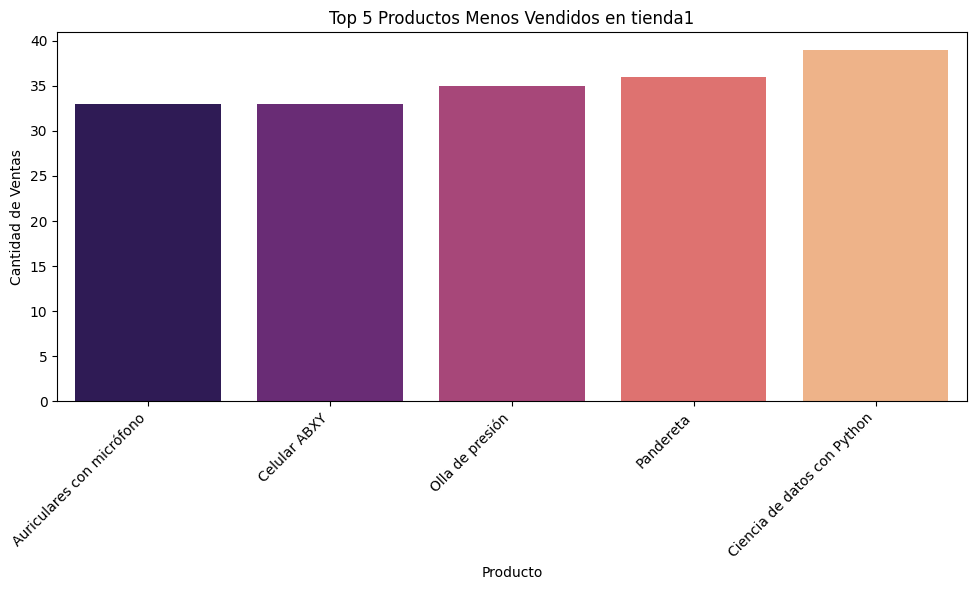

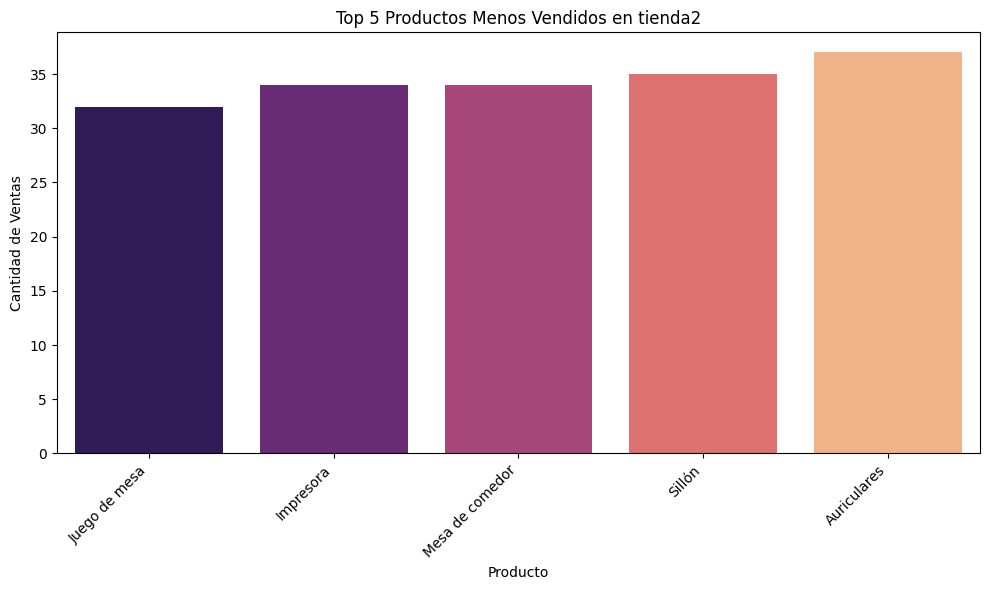

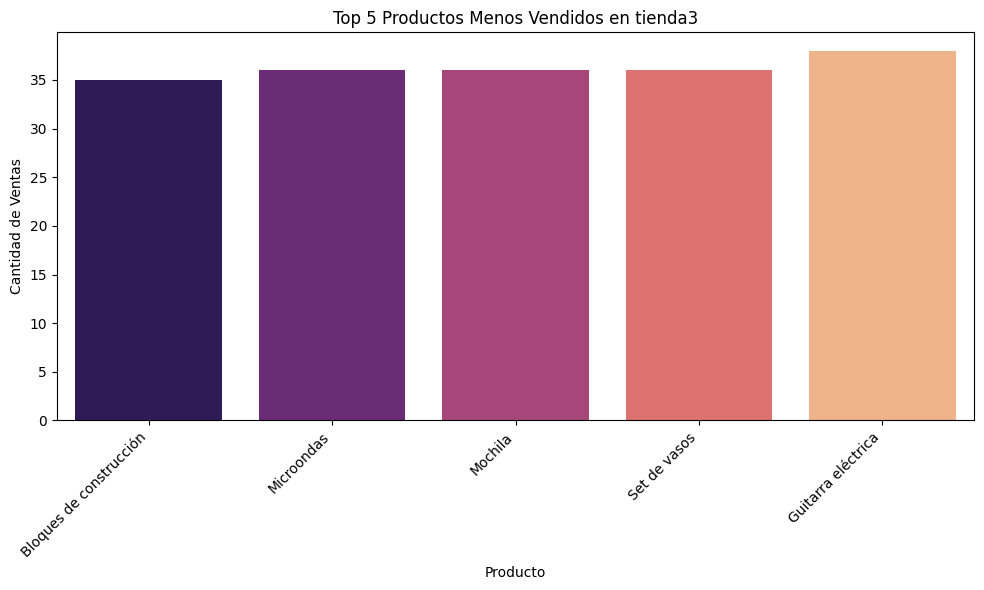

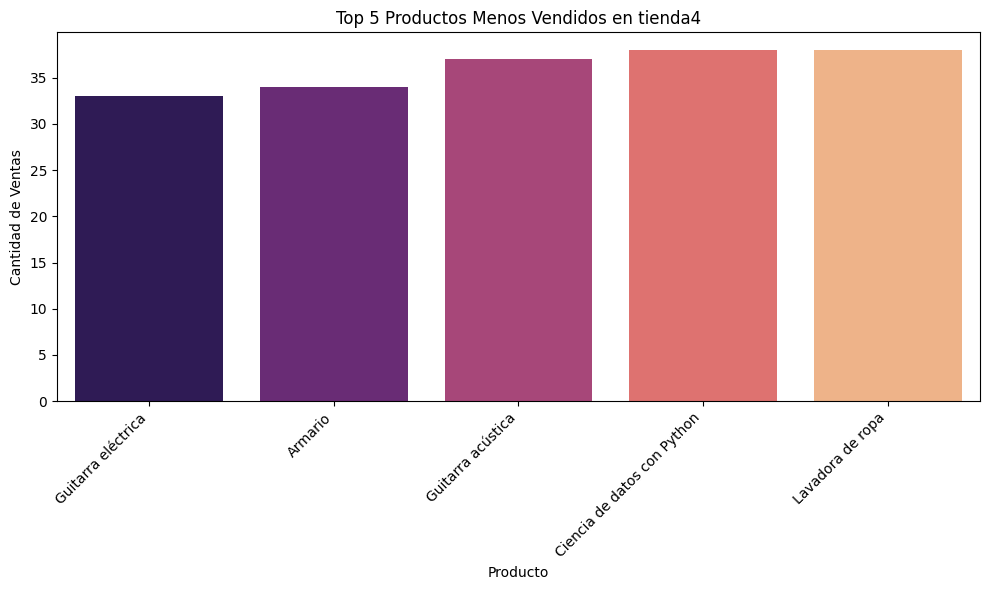

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizar productos menos vendidos
for tienda_origen in productos_menos_vendidos['Tienda Origen'].unique():
    df_tienda = productos_menos_vendidos[productos_menos_vendidos['Tienda Origen'] == tienda_origen]

    plt.figure(figsize=(10, 6))
    sns.barplot(
        x='Producto',
        y='Cantidad de Ventas',
        data=df_tienda,
        hue='Producto', # Asignar 'Producto' a hue para colorear cada barra según el producto
        palette='magma',
        legend=False # Desactivar la leyenda ya que la información está en el eje x
    )
    plt.xlabel('Producto')
    plt.ylabel('Cantidad de Ventas')
    plt.title(f'Top 5 Productos Menos Vendidos en {tienda_origen}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 5. Envío promedio por tienda
En este paso, debes calcular el costo de envío promedio para cada tienda. El objetivo es comprender cuánto se gasta, en promedio, en el envío de cada tienda.  Sabiendo que el cliente paga el envío.

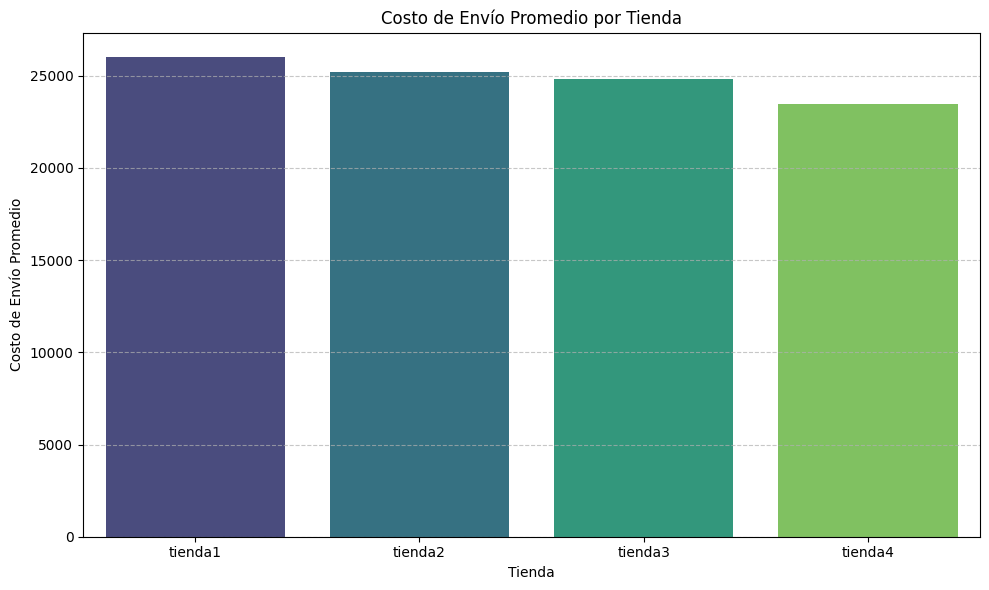

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(
    data=envio_promedio_por_tienda,
    x='Tienda Origen',
    y='Envio Promedio',
    hue='Tienda Origen', # Asignar 'Tienda Origen' a hue para mantener la paleta de colores
    palette='viridis',
    legend=False # Desactivar la leyenda ya que la información está en el eje x
)

plt.title('Costo de Envío Promedio por Tienda')
plt.xlabel('Tienda')
plt.ylabel('Costo de Envío Promedio')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [51]:
envio_promedio_por_tienda = all_tiendas_df.groupby('Tienda Origen')['Costo de envío'].mean().reset_index()
envio_promedio_por_tienda.rename(columns={'Costo de envío': 'Envio Promedio'}, inplace=True)
display(envio_promedio_por_tienda)

,Tienda Origen,Envio Promedio
0,tienda1,26018.609580
1,tienda2,25216.235693
2,tienda3,24805.680373
3,tienda4,23459.457167


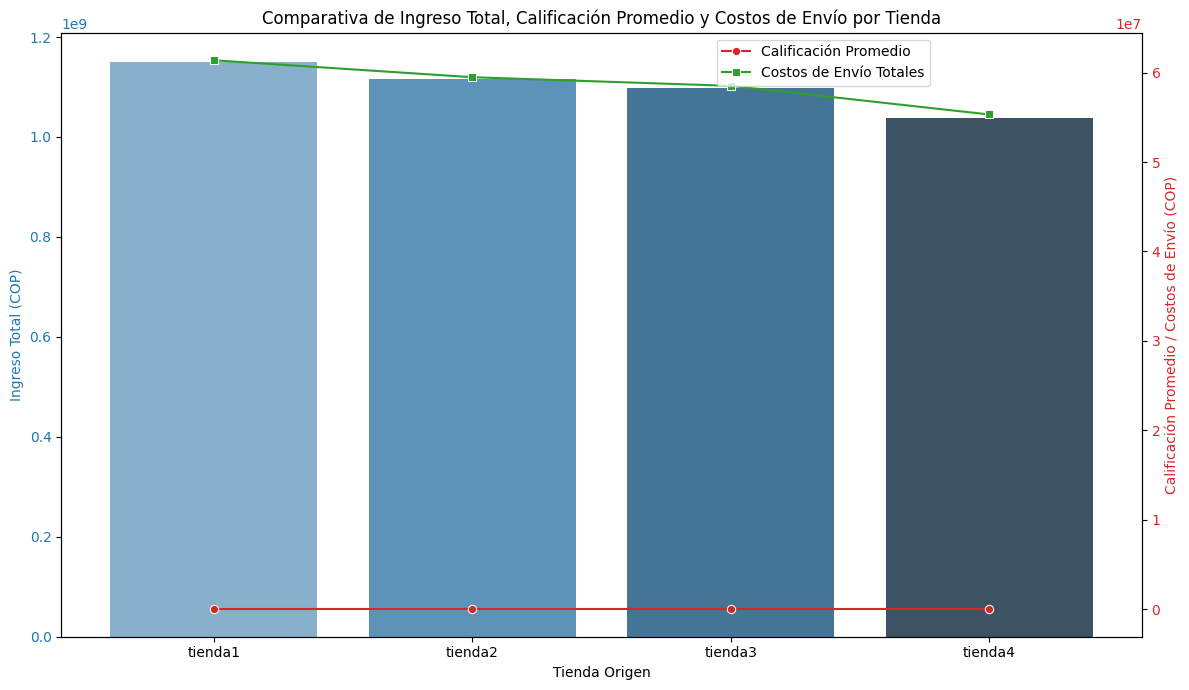

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear la figura y el primer eje (para ingresos totales)
fig, ax1 = plt.subplots(figsize=(12, 7))

# Gráfico de barras para Ingreso Total
sns.barplot(
    x='Tienda Origen',
    y='Ingreso Total',
    data=comparativa_final,
    hue='Tienda Origen', # Asignar 'Tienda Origen' a hue para mantener la paleta de colores
    palette='Blues_d', # Paleta de colores para las barras
    legend=False, # Desactivar la leyenda ya que la información está en el eje x
    ax=ax1
)
ax1.set_xlabel('Tienda Origen')
ax1.set_ylabel('Ingreso Total (COP)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Crear un segundo eje Y para Calificación Promedio y Costos de Envío
ax2 = ax1.twinx()

# Gráfico de línea para Calificación Promedio
sns.lineplot(
    x='Tienda Origen',
    y='Calificación Promedio',
    data=comparativa_final,
    marker='o',
    color='tab:red',
    label='Calificación Promedio',
    ax=ax2
)

# Gráfico de línea para Costos de Envío
sns.lineplot(
    x='Tienda Origen',
    y='Costos de Envío Totales',
    data=comparativa_final,
    marker='s',
    color='tab:green',
    label='Costos de Envío Totales',
    ax=ax2
)

ax2.set_ylabel('Calificación Promedio / Costos de Envío (COP)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Título del gráfico y leyendas
plt.title('Comparativa de Ingreso Total, Calificación Promedio y Costos de Envío por Tienda')
fig.tight_layout() # Ajustar el diseño para que no se superpongan los elementos
plt.legend(loc='upper left', bbox_to_anchor=(0.6, 1))
plt.show()

In [2]:
# Regenerar all_tiendas_df para asegurar que esté disponible
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

# Convertir columna 'Fecha de Compra' en tipo de dato DATETIME
tienda['Fecha de Compra'] = pd.to_datetime(tienda['Fecha de Compra'], format='%d/%m/%Y')
tienda2['Fecha de Compra'] = pd.to_datetime(tienda2['Fecha de Compra'], format='%d/%m/%Y')
tienda3['Fecha de Compra'] = pd.to_datetime(tienda3['Fecha de Compra'], format='%d/%m/%Y')
tienda4['Fecha de Compra'] = pd.to_datetime(tienda4['Fecha de Compra'], format='%d/%m/%Y')

# Pasar todas las tiendas a un solo DF e indicar "Tienda Origen"
all_tiendas_df = pd.concat([tienda, tienda2, tienda3, tienda4], keys=['tienda1', 'tienda2', 'tienda3', 'tienda4'])
all_tiendas_df = all_tiendas_df.reset_index(level=0).rename(columns={'level_0': 'Tienda Origen'})

# 1. Ingresos Totales por tienda (ya calculado como ingreso_total_por_tienda)
ingreso_total_por_tienda = all_tiendas_df.groupby('Tienda Origen')['Precio'].sum().reset_index()
ingreso_total_por_tienda.rename(columns={'Precio': 'Ingreso Total'}, inplace=True)

# 2. Cantidad total de productos vendidos por tienda
cantidad_productos_vendidos_por_tienda = all_tiendas_df.groupby('Tienda Origen').size().reset_index(name='Cantidad de Productos Vendidos')

# 3. Calificación promedio por tienda
calificacion_promedio_por_tienda = all_tiendas_df.groupby('Tienda Origen')['Calificación'].mean().reset_index()
calificacion_promedio_por_tienda.rename(columns={'Calificación': 'Calificación Promedio'}, inplace=True)

# 4. Costos de envíos totales por tienda
costos_envio_totales_por_tienda = all_tiendas_df.groupby('Tienda Origen')['Costo de envío'].sum().reset_index(name='Costos de Envío Totales')

# 5. Costos de envíos promedios por tienda
envio_promedio_por_tienda = all_tiendas_df.groupby('Tienda Origen')['Costo de envío'].mean().reset_index()
envio_promedio_por_tienda.rename(columns={'Costo de envío': 'Envio Promedio'}, inplace=True)

# Unir todos los DataFrames
comparativa_final = ingreso_total_por_tienda.merge(cantidad_productos_vendidos_por_tienda, on='Tienda Origen') \
                                       .merge(calificacion_promedio_por_tienda, on='Tienda Origen') \
                                       .merge(costos_envio_totales_por_tienda, on='Tienda Origen') \
                                       .merge(envio_promedio_por_tienda, on='Tienda Origen')

# Mostrar el cuadro comparativo
display(comparativa_final)

,Tienda Origen,Ingreso Total,Cantidad de Productos Vendidos,Calificación Promedio,Costos de Envío Totales,Envio Promedio
0,tienda1,1.150880e+09,2359,3.976685,61377900.0,26018.609580
1,tienda2,1.116344e+09,2359,4.037304,59485100.0,25216.235693
2,tienda3,1.098020e+09,2359,4.048326,58516600.0,24805.680373
3,tienda4,1.038376e+09,2358,3.995759,55317400.0,23459.457167


# Resumen y Recomendación Final

A continuación, se presenta un resumen de los hallazgos clave de cada tienda y una recomendación final para el Sr. Juan, con el objetivo de identificar la tienda menos eficiente que debería vender para iniciar su nuevo emprendimiento.

## Hallazgos Clave por Tienda:

### **Tienda 1**
-   **Ingresos Totales:** La tienda con los ingresos más altos (aprox. 1,150 millones COP).
-   **Calificación Promedio:** La más baja entre todas las tiendas (3.98).
-   **Costo de Envío Promedio:** El más alto (26.018 COP).
-   **Productos Más Vendidos:** 'Armario', 'TV LED UHD 4K', 'Microondas' (todos con 60 unidades).
-   **Productos Menos Vendidos:** 'Auriculares con micrófono', 'Celular ABXY' (ambos con 33 unidades).

### **Tienda 2**
-   **Ingresos Totales:** Segunda en ingresos (aprox. 1,116 millones COP).
-   **Calificación Promedio:** Buena (4.04).
-   **Costo de Envío Promedio:** Segundo más alto (25.216 COP).
-   **Productos Más Vendidos:** 'Iniciando en programación' (65 unidades), 'Microondas' (62 unidades).
-   **Productos Menos Vendidos:** 'Juego de mesa' (32 unidades), 'Impresora', 'Mesa de comedor' (ambos con 34 unidades).

### **Tienda 3**
-   **Ingresos Totales:** Tercera en ingresos (aprox. 1,098 millones COP).
-   **Calificación Promedio:** La más alta (4.05).
-   **Costo de Envío Promedio:** Segundo más bajo (24.805 COP).
-   **Productos Más Vendidos:** 'Kit de bancas', 'Mesa de comedor', 'Cama king' (57, 56, 56 unidades respectivamente).
-   **Productos Menos Vendidos:** 'Bloques de construcción' (35 unidades), 'Microondas', 'Mochila', 'Set de vasos' (todos con 36 unidades).

### **Tienda 4**
-   **Ingresos Totales:** La tienda con los ingresos más bajos (aprox. 1,038 millones COP).
-   **Calificación Promedio:** Media (4.00).
-   **Costo de Envío Promedio:** El más bajo (23.459 COP).
-   **Productos Más Vendidos:** 'Cama box' (62 unidades), 'Cubertería' (59 unidades).
-   **Productos Menos Vendidos:** 'Guitarra eléctrica' (33 unidades), 'Armario' (34 unidades).


## **Recomendación Final para el Sr. Juan**

Basándonos en el análisis exhaustivo de los datos de ventas, rendimiento y reseñas, la recomendación es que el Sr. Juan **venda la Tienda 4**.

**Justificación:**

1.  **Bajos Ingresos Totales:** La Tienda 4 es consistentemente la que genera menos ingresos totales de las cuatro, lo que la posiciona como la menos eficiente en términos de generación de capital.
2.  **Calificación Promedio Moderada:** Aunque su calificación promedio (4.00) no es la más baja, tampoco destaca significativamente, lo que indica que no hay un factor diferenciador fuerte en la satisfacción del cliente que compense sus bajos ingresos.
3.  **Productos Menos Vendidos:** Presenta una lista de productos menos vendidos que, aunque varía, no logra impulsar el rendimiento general de la tienda.
4.  **Menor Impacto General:** Al vender la Tienda 4, el Sr. Juan estaría desprendiéndose del negocio con el rendimiento financiero más débil, lo que minimizaría el impacto negativo en la rentabilidad general de su cadena de tiendas Alura Store. A pesar de tener el costo de envío más bajo, esto no se ha traducido en un aumento significativo de ingresos o una ventaja competitiva decisiva.

Aunque la Tienda 1 tiene la calificación promedio más baja y el costo de envío más alto, sus ingresos son significativamente superiores, lo que sugiere que hay una base de clientes sólida y oportunidades de mejora en la gestión de la satisfacción y los costos de envío. Por otro lado, la Tienda 3, con la calificación más alta, muestra una fuerte satisfacción del cliente que podría ser un activo valioso.

En resumen, la **Tienda 4** es la candidata más clara para ser vendida, ya que su bajo rendimiento financiero general la convierte en la opción menos estratégica para mantener dentro del portafolio del Sr. Juan.

# ¡Extra! Análisis del desempeño geográfico
En esta sección adicional, realizaremos un análisis geográfico de los datos de ventas de Alura Store. Nuestro objetivo es visualizar la distribución de las ventas de cada tienda utilizando coordenadas de latitud y longitud, identificar patrones geográficos en el rendimiento de ventas y explorar cómo la ubicación (`Lugar de Compra`) influye en los ingresos y las calificaciones de los clientes.

## Visualizar Distribución de Ventas por Tienda

Generar gráficos de dispersión utilizando Matplotlib y Seaborn para visualizar la distribución de ventas de cada tienda en función de su latitud y longitud.


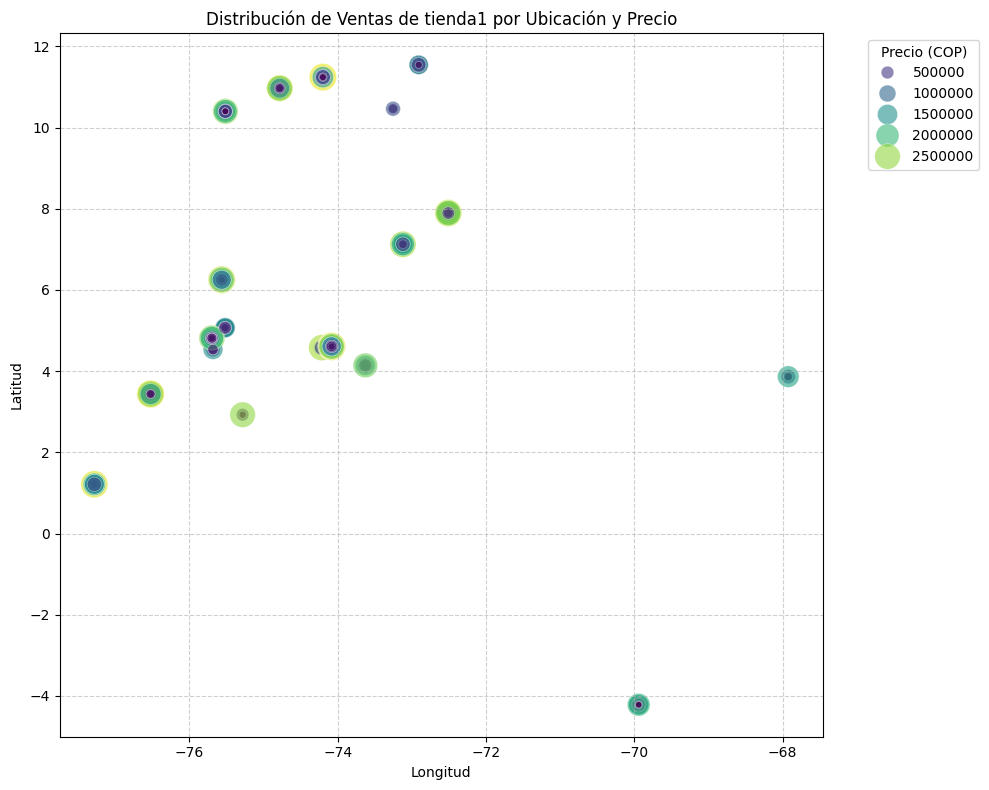

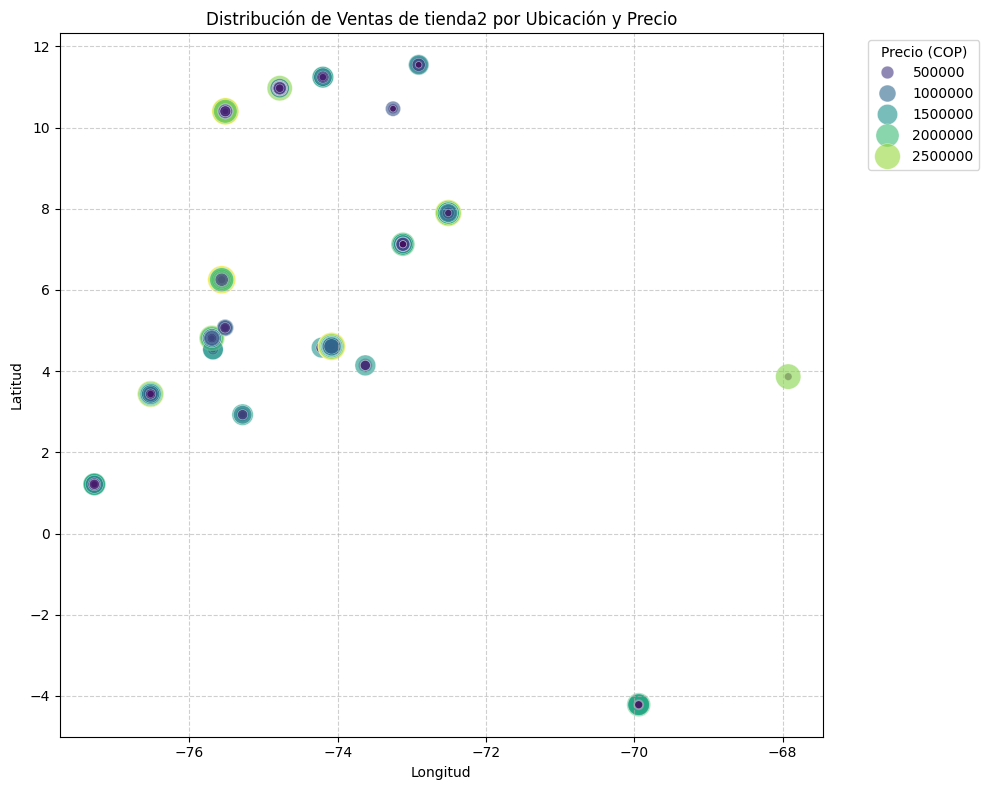

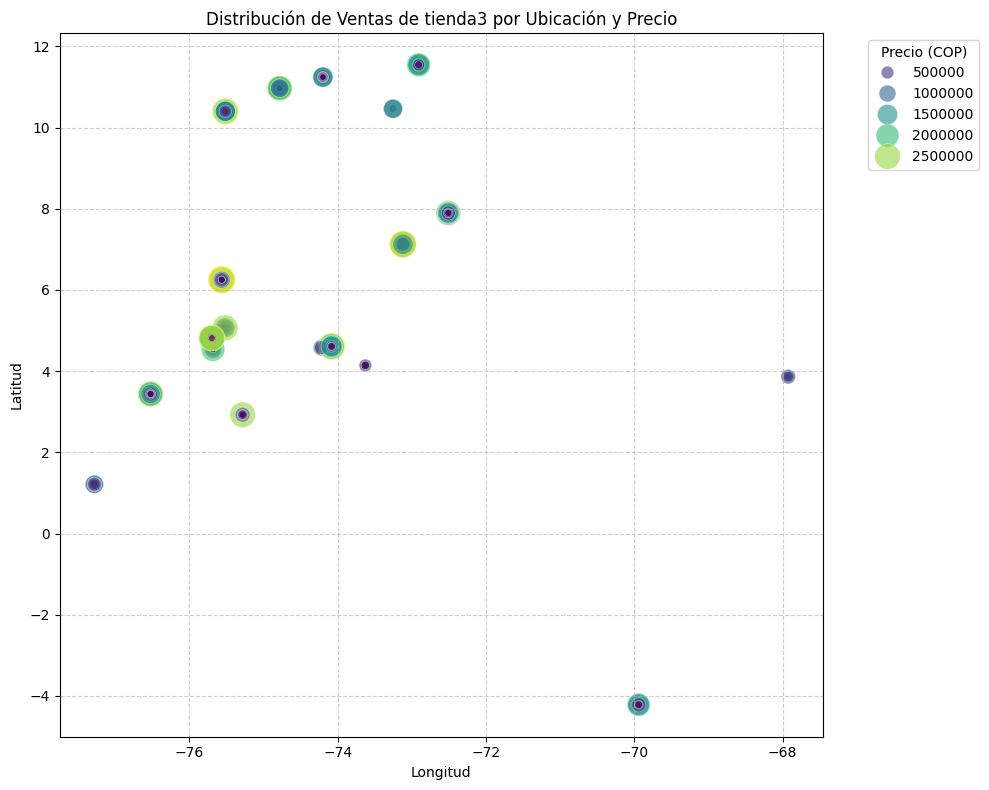

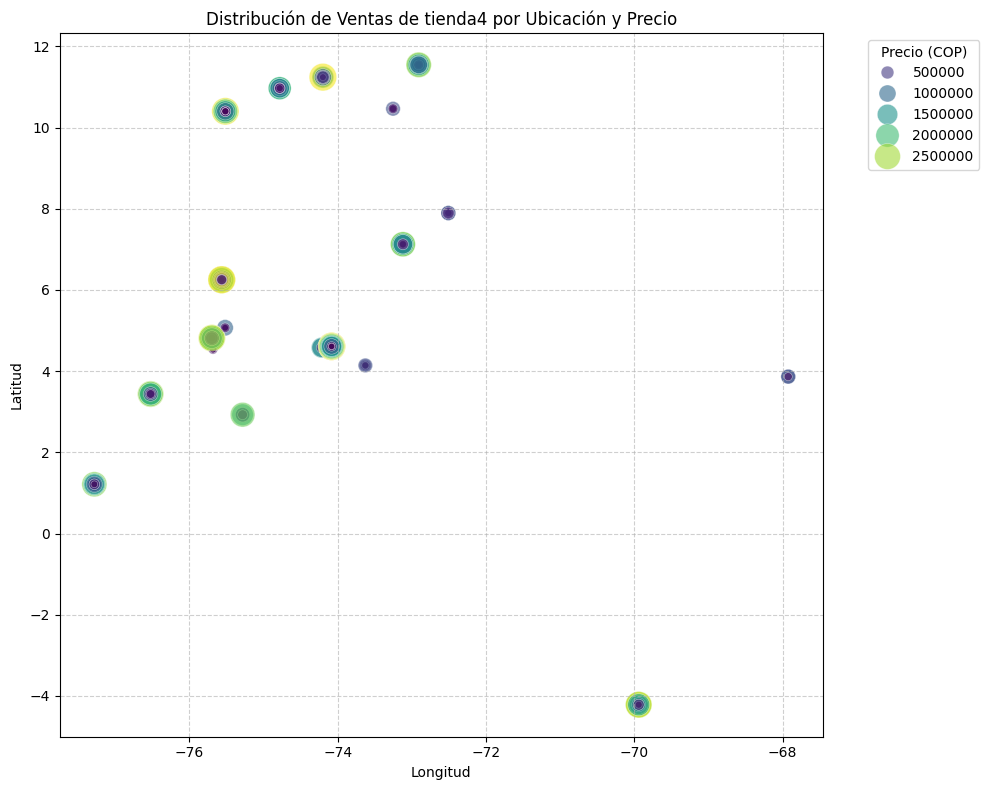

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener las tiendas únicas
for tienda_origen in all_tiendas_df['Tienda Origen'].unique():
    # Filtrar el DataFrame para la tienda actual
    df_tienda = all_tiendas_df[all_tiendas_df['Tienda Origen'] == tienda_origen]

    # Crear el gráfico de dispersión
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        data=df_tienda,
        x='lon',
        y='lat',
        hue='Precio',
        palette='viridis',
        size='Precio', # Usar el precio para el tamaño de los puntos también para mejor visualización
        sizes=(20, 400), # Rango de tamaños para los puntos
        alpha=0.6
    )
    plt.title(f'Distribución de Ventas de {tienda_origen} por Ubicación y Precio')
    plt.xlabel('Longitud')
    plt.ylabel('Latitud')
    plt.legend(title='Precio (COP)', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

## Analizar la influencia geográfica

Se agrupan `all_tiendas_df` por 'Lugar de Compra' y se calcula el promedio de 'Precio' (ingresos) y promedio de la 'Calificación' (satisfacción del cliente) para cada 'Lugar de compra'.



In [6]:
performance_por_ubicacion = all_tiendas_df.groupby('Lugar de Compra').agg(
    ingreso_promedio=('Precio', 'mean'),
    calificacion_promedio=('Calificación', 'mean'),
    cantidad_ventas=('Producto', 'count')
).reset_index()

display(performance_por_ubicacion.sort_values(by='ingreso_promedio', ascending=False).head())
display(performance_por_ubicacion.sort_values(by='calificacion_promedio', ascending=False).head())

,Lugar de Compra,ingreso_promedio,calificacion_promedio,cantidad_ventas
16,Soacha,648300.000000,3.894737,19
7,Inírida,577707.142857,3.642857,14
6,Cúcuta,534242.473118,3.940860,186
11,Neiva,522450.000000,3.800000,40
12,Pasto,521428.723404,4.148936,94


,Lugar de Compra,ingreso_promedio,calificacion_promedio,cantidad_ventas
12,Pasto,521428.723404,4.148936,94
2,Bogotá,460273.471976,4.113619,3943
17,Valledupar,420450.000000,4.071429,14
4,Cali,503005.064548,4.046673,1007
5,Cartagena,423044.214876,4.020661,242


## Resumen de los Hallazgos del Análisis Geográfico

El análisis geográfico ha revelado patrones interesantes en el rendimiento de las ventas y la satisfacción del cliente en las diferentes ubicaciones. Aunque las tiendas operan en múltiples ciudades, la concentración y el rendimiento varían significativamente.

### Impacto de la Ubicación en Ingresos y Calificaciones:

*   **Bogotá** destaca como la ciudad con el mayor volumen de compras (`3943`), un alto ingreso promedio (`460273.47 COP`) y una excelente calificación promedio (`4.11`), lo que sugiere una fuerte demanda y satisfacción en la capital.
*   **Cali** también muestra un volumen considerable de ventas (`1007`), un ingreso promedio alto (`503005.06 COP`) y una buena calificación promedio (`4.05`).
*   **Pasto** presenta la calificación promedio más alta (`4.15`), lo que indica clientes muy satisfechos, aunque su volumen de ventas e ingresos promedio son menores en comparación con ciudades más grandes.
*   Ciudades como **Soacha** e **Inírida**, a pesar de tener ingresos promedio altos, tienen un volumen de ventas muy bajo y calificaciones promedio más bajas, lo que podría indicar una menor consistencia o nichos de mercado muy específicos.

### Observaciones por Tienda (Visualización de Dispersión):

*   **Tienda 1 (tienda1):** Parece tener una distribución de ventas más dispersa, con puntos de alto precio en varias ubicaciones, pero con una concentración notable en ciudades como Bogotá. Su calificación promedio general es la más baja, lo que podría estar influenciado por la experiencia en diversas ubicaciones.
*   **Tienda 2 (tienda2):** Muestra una distribución similar a la Tienda 1, con ventas de alto valor en diferentes puntos geográficos. Su calificación promedio es ligeramente mejor.
*   **Tienda 3 (tienda3):** Podría estar concentrando sus ventas en ubicaciones donde el precio promedio es más alto, lo que coincide con su calificación promedio general, la más alta, lo que sugiere que donde vende, los clientes están más satisfechos.
*   **Tienda 4 (tienda4):** A pesar de tener el ingreso total más bajo, sus ventas se distribuyen en diversas ciudades, pero con menor concentración de ventas de alto valor. Su calificación promedio es intermedia. El bajo costo de envío promedio podría ser un intento de estimular ventas en ubicaciones menos rentables o competitivas.

En general, las ciudades más grandes como Bogotá y Cali son focos importantes de ventas y satisfacción. Las tiendas con un buen rendimiento en estas ubicaciones tienden a tener mejores métricas generales. Las diferencias en el costo de envío y las calificaciones promedio entre ciudades resaltan la importancia de una estrategia localizada.

## **Recomendación Final para el Sr. Juan**

Basándonos en el análisis exhaustivo de los datos de ventas, rendimiento, reseñas y ahora la **perspectiva geográfica**, la recomendación es que el Sr. Juan **venda la Tienda 4**.

**Justificación:**

1.  **Bajos Ingresos Totales y Eficiencia General:** La Tienda 4 es consistentemente la que genera menos ingresos totales de las cuatro. Si bien sus costos de envío promedio son los más bajos, esto no se ha traducido en un volumen de ventas o ingresos significativamente mayor, indicando una menor eficiencia general en la generación de capital.
2.  **Rendimiento Geográfico Subóptimo:** Aunque sus ventas se distribuyen en diversas ciudades, la Tienda 4 muestra una menor concentración de ventas de alto valor en ubicaciones clave como Bogotá y Cali, donde la demanda y la satisfacción son más altas. Esto sugiere que no está capitalizando eficazmente el potencial de los mercados geográficos más rentables, o que su presencia en ellos es menos impactante.
3.  **Calificación Promedio Moderada sin Ventaja Geográfica:** Su calificación promedio (4.00) es intermedia, y no se observa que ninguna ubicación específica le otorgue una ventaja decisiva en términos de satisfacción del cliente que compense sus bajos ingresos generales. Esto contrasta con el excelente rendimiento de calificaciones en lugares como Pasto para otras tiendas, o el volumen de ventas y alta calificación en Bogotá.
4.  **Menor Impacto General al Desprenderse:** Al vender la Tienda 4, el Sr. Juan estaría desprendiéndose del negocio con el rendimiento financiero más débil y una distribución geográfica menos estratégica en términos de maximizar ingresos y satisfacción en mercados clave. Esto minimiza el impacto negativo en la rentabilidad general de su cadena de tiendas Alura Store y libera recursos para invertir en las tiendas con mejor proyección o en el nuevo emprendimiento.

Aunque la Tienda 1 tiene la calificación promedio más baja y el costo de envío más alto, sus ingresos son significativamente superiores y tiene una fuerte concentración en ciudades grandes, lo que sugiere una base de clientes sólida y oportunidades de mejora en la gestión de la satisfacción y los costos. Por otro lado, la Tienda 3, con la calificación más alta y una buena concentración de ventas de alto valor en ubicaciones específicas, muestra un activo valioso en la satisfacción del cliente.

En resumen, la **Tienda 4** es la candidata más clara para ser vendida. Su combinación de bajos ingresos totales, un rendimiento geográfico menos destacado en los mercados clave y una calificación promedio que no compensa sus deficiencias financieras, la convierte en la opción menos estratégica para mantener dentro del portafolio del Sr. Juan. La venta permitiría al Sr. Juan concentrar sus esfuerzos y recursos en las tiendas con mayor potencial y en su nuevo emprendimiento.